# Iterative Workflow :


In [15]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph , START , END
from typing import TypedDict , Literal , Annotated
from langchain_core.messages import SystemMessage , HumanMessage
from dotenv import load_dotenv
import operator 

In [16]:
load_dotenv()

True

In [17]:
generator_llm = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    temperature=0.7
)

evaluator_llm = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    temperature=0
)

optimization_llm = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    temperature=0.3
)

In [18]:
# Schema : For structured output : 

from pydantic import BaseModel , Field

class TweetEvaluation(BaseModel):
    evaluation : Literal['approved' , 'needs_improvement'] = Field(... , description= 'Final evaluation result.')
    feedback : str = Field(... , description= "feedback for the tweet.")

In [19]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [20]:
# Define state :

class TweetState(TypedDict):
    topic : str
    tweet : str 
    evaluation : Literal['approved' , 'needs_improvement']
    feedback : str
    iteration : int
    max_iteration : int

    tweet_history : Annotated[list[str] , operator.add]
    feedback_history : Annotated[list[str] , operator.add]

In [21]:
# tasks : 

def generate_tweet(state : TweetState):
    # Prompt : 

      # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
            Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

            Rules:
            - Do NOT use question-answer format.
            - Max 280 characters.
            - Use observational humor, irony, sarcasm, or cultural references.
            - Think in meme logic, punchlines, or relatable takes.
            - Use simple, day to day english
            """)
                ]


    # send generator_llm : 

    response = generator_llm.invoke(messages).content

    # return response :

    return {
        'tweet' :  response, 
        'tweet_history' : [response]  
        }

In [22]:
def optimize_tweet(state : TweetState):

        # prompt
        messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
            Improve the tweet based on this feedback:
            "{state['feedback']}"

            Topic: "{state['topic']}"
            Original Tweet:
            {state['tweet']}

            Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
            """)
                ]

        response = optimization_llm.invoke(messages).content

        iteration = state['iteration'] + 1

        return {
            'tweet' : response,
            'iteration' : iteration,
            'tweet_history' : [response]  

        }        

In [23]:
def evaluate_tweet(state: TweetState):

    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback , 'feedback_history' : [response.feedback]}

In [24]:
# Conditional fxn : 

def route_evaluation(state : TweetState) :
    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration'] :
          return 'approved'
    else :
         return 'needs_improvement'
          

In [25]:
# Graph :

graph = StateGraph(TweetState)

# Add Node :

graph.add_node('generate', generate_tweet)
graph.add_node('evaluate', evaluate_tweet)
graph.add_node('optimize', optimize_tweet)

# Edges :

graph.add_edge(START , 'generate')
graph.add_edge('generate' , 'evaluate')


graph.add_conditional_edges('evaluate' , route_evaluation , {'approved' : END , 'needs_improvement' : 'optimize'} )

graph.add_edge('optimize'  , 'evaluate') # loop


# Compile : 

workflow = graph.compile()



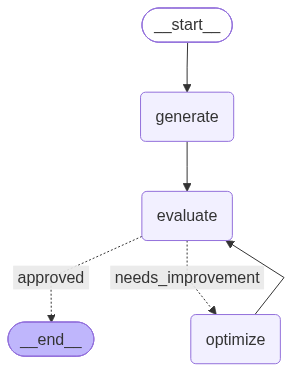

In [26]:
workflow

In [27]:
# execute : 

initial_state = {
    'topic' : 'Genz',
    'iteration' : 1,
    'max_iteration' : 3
}

workflow.invoke(initial_state)

/media/ayush-paliwal/PROJECTS/LangChain LangGraph & RAG Components/.venv/lib/python3.12/site-packages/langchain_google_genai/chat_models.py:3120: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
/media/ayush-paliwal/PROJECTS/LangChain LangGraph & RAG Components/.venv/lib/python3.12/site-packages/langchain_google_genai/chat_models.py:3120: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


{'topic': 'Genz',
 'tweet': [{'type': 'text',
   'text': 'Gen Z can watch a movie with subtitles, scroll TikTok, and play a mobile game all at the same time, but if you call them without texting first, they stare at their screen like it’s an active pipe bomb.',
   'extras': {'signature': 'EuUmCuImARFNMg/3nBrTF/ib6Jid2s3ExXAOayEAgdGcOHP3SrxfVxhuF/TcAID3REHTczCPd1N1d2MiixOdgh/aMmrTOEZlLFEYYWjsfWr5OL1Bk7asu5kfinKMwzaeWNFIw4BSwHuoUy2w9H2zirDGtI6msdxk/qINOd+fyXxBEdst28nqqVk88uQ1yCQMkUFbiqg7XrcGTORCgizjCo++Qw7EX/bcNwteZY3XUBXranApqkP1Rd7cmNOApmQx5NXyJ7kBMFliYM0zUMuRAFtqmNJgGirf+3+2vz+E2PIZf1OMhP4QWh8F68VHUKGvC5UlcsHKn9oGsbKLT+Z5O9vWZpmgZlnuzqUpm/gLOgS6zEEu9Mm9BcG5ZMPsN380EwV4Oiv7jSZMy8+dRYkGdmAlMdA4s6qoaOAgev5aU5ixWaEiUTuJbQ2MvSPwXDiw0eBZMJX//v5EvlLiS4rt0GpXJ3zCdeqEd0xKc87yKlay8MvXY+iusRUD+kPC6/VHDMF1F6uYpwxHXj/DxdBzZSyirJ0DiPZSFCV26W4vffyF/auHcjruj83PiZNm8/bYLQ2ztOY4+7VcJGg3JrH9m02lqAr4vLDNI1KrwWxnqhhl75Olbi8lf3bfUswu5bQ4YnTgJHbfwsm585A/TWr6V0rPLv04xqfuHlxyqT5+IxBzuHcvZNQdXkG67GjnW+IPRS+Yif